# 第26课 · 🎨 亲眼看见「下山」— 切线（tangent line）、等高线（contour line）与梯度下降（gradient descent）轨迹

> **🎨 读法**：L22–L25 的眼睛版。旁白保持短——**见图：步长过大如何震荡、等高线与负梯度如何指向谷底**。不必重讲 GD 全文。

← **上一课**　[L25 · 梯度下降](L25_gradient_descent.ipynb)

> 上节课学习了 **梯度下降**：蒙眼下山、沿负梯度走到谷底，从损失函数到权重更新公式。  
> 本课将探讨 **微积分可视化**。

## 本课剧情：把坡度画出来

切线斜率说明函数在某点的变化方向，梯度把这个方向推广到多维，梯度下降则沿梯度反方向一步步走向最低点。这节课用 `tangent`、`descent_1d`、`contour_descent` 把三件事各画一张图，再用 `lr_compare` 对比三种学习率（learning rate，lr）的收敛行为。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
from cviz import style, tangent, descent_1d, contour_descent, lr_compare
style(); print('cviz 就绪')

cviz 就绪


## 走进微积分可视化：从导数的数值近似开始

导数 $f'(x)$ 是一个**瞬间的变化率**。在 L22 里我们学过：
$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

这个极限在理论上很漂亮，但在计算机里无法真的取极限。我们用「有限小的 h」来近似，即**数值微分**。

**一个自然的疑问**：既然导数定义用的是 $f(x+h) - f(x)$，为什么我们常用 $f(x+h) - f(x-h)$ 呢？

最朴素的答案是：对称性更好。直线 $y = f(x)$ 在点 $x$ 附近，从左边和右边同时看，能互相校正一些误差。这就是**中心差分（central difference）**的思想。用数学语言：单向差分的误差阶是 $O(h)$，中心差分能降到 $O(h^2)$，即步长 h 越小，精度提升得更快。

## 实验入口：用数值变化观察函数

用中心差分（central difference，CD） `(f(x+h)−f(x−h))/(2h)` 在五个点上算 `f(x) = x²` 的近似斜率，和理论值 `2x` 逐行对照。

## 动手观察：变化率不是一句口号

对 `f(x) = x²` 取 `h = 1e-3`，中心差分的结果和理论值 `2x` 精确到小数点后三位。

In [3]:
import numpy as np

def f(x):
    return x**2

xs = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
h = 1e-3
slopes = (f(xs + h) - f(xs - h)) / (2 * h)

print('x =', xs)
print('f(x) =', f(xs))
print('近似斜率 =', np.round(slopes, 3))
print('理论斜率 2x =', 2 * xs)


x = [-2. -1.  0.  1.  2.]
f(x) = [4. 1. 0. 1. 4.]
近似斜率 = [-4. -2.  0.  2.  4.]
理论斜率 2x = [-4. -2.  0.  2.  4.]


### 为什么是 2h，不是 h？

看上面的代码，分子是 $f(x+h) - f(x-h)$，这两个点的距离是多少？
- 点 $(x-h)$ 到 $(x+h)$ 的距离是 $(x+h) - (x-h) = 2h$

所以变化率（高度变化 ÷ 水平距离）的分母必然是 $2h$，而不是 $h$。这就像在一条山路上，从左边走 h，再从右边走 h，两边加起来的总距离是 $2h$。

再强调一遍公式：
$$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$$

## 练习：实现中心差分并验证精度

**任务**：补全 `central_diff(f, x, h)` 的实现，然后对 `f(x) = x²` 在 `x = 1.5` 处验证：
- 数值导数与理论值 `2 x 1.5 = 3.0` 的误差小于 `1e-6`
- 单步负梯度更新后函数值严格下降：`f(x - lr*slope) < f(x)`

完成后运行断言，若通过则打印「验证通过」。

In [4]:
def central_diff(f, x, h=1e-5):
    """用中心差分近似 f 在 x 处的一阶导数。
    参数:
        f : 可调用，接受标量返回标量
        x : float，求导点
        h : float，步长（默认 1e-5）
    返回: float
    """
    raise NotImplementedError("请实现中心差分公式：(f(x+h) - f(x-h)) / (2*h)")

# --- 验证区 ---
try:
    import numpy as np
    f_sq = lambda x: x**2
    x0, lr = 1.5, 0.1
    slope = central_diff(f_sq, x0)
    assert abs(slope - 2 * x0) < 1e-6, f'误差过大：{abs(slope - 2*x0):.2e}，检查公式分母是否为 2h'
    x_new = x0 - lr * slope
    assert f_sq(x_new) < f_sq(x0), '一步负梯度更新后 f 未下降，检查符号是否为减'
    print('验证通过：中心差分误差', f'{abs(slope - 2*x0):.2e}', '函数値', f_sq(x0), '->', f'{f_sq(x_new):.4f}')
except (NotImplementedError, TypeError) as e:
    print(f'[TODO] {e}')


[TODO] 请实现中心差分公式：(f(x+h) - f(x-h)) / (2*h)


### 为什么「负梯度更新」一定会降低函数值？

验证代码里检查了 `f(x - lr*slope) < f(x)`，即「负梯度方向的一小步」能让函数值下降。这不是巧合，而是有数学保证的。

**泰勒展开的启示**：在点 $x$ 附近，用一阶泰勒近似：
$$f(x + \Delta x) \approx f(x) + f'(x) \cdot \Delta x$$

如果我们选择 $\Delta x = -\text{lr} \cdot f'(x)$（即沿负梯度方向走），那么：
$$f(x - \text{lr} \cdot f'(x)) \approx f(x) - \text{lr} \cdot (f'(x))^2$$

关键观察：$(f'(x))^2 \geq 0$ 总是非负的（平方数）。所以：
$$f(x - \text{lr} \cdot f'(x)) \approx f(x) - \text{lr} \cdot (\text{非负}) \leq f(x)$$

当 $f'(x) \neq 0$ 时（即不在极值点），右边的不等式是严格的 $<$，函数值严格下降。

**条件**：这个论证假设步长 $\text{lr}$ 足够小，使得一阶泰勒近似足够准确。如果 $\text{lr}$ 太大，高阶项就会起作用，可能破坏下降性质。这又回到了「学习率的平衡」这个话题。

### ⚠️ h 的选择：不是越小越好

初学者常问：「h 这么重要，那 h=1e-10 或 1e-20 行不行，能让误差更小吗？」

**答案是不行。** 有一个隐藏的陷阱：**浮点数精度**。

计算机用二进制存储浮点数，精度是有限的（比如 64 位浮点数约 15-16 位有效数字）。当 h 太小时：
- $f(x+h)$ 和 $f(x-h)$ 的值会非常接近（比如都约等于 $f(x)$）
- 相减时，接近的两个大数相减，有效数字会严重损失，反而引入**舍入误差**

打个比方：你有个精度为「小数点后5位」的天平，两个重物都显示 100.00000 kg，你拿它们的差来估计，得到的结果就没意义了。

**实践选择**：
- h = 1e-5 到 1e-7 通常是安全的平衡点，既让中心差分公式精确，又避免舍入误差
- 对 f(x)=x² 这样的多项式，h=1e-5 的误差可以达到 1e-8 甚至更好
- 如果函数更复杂（如有很高的导数项），可能需要稍大的 h

## 代码实验：遍历不同位置，看斜率如何变化

对 `f(x) = x² + 2x` 从 `x = −3` 到 `x = 3` 逐点打印函数值和斜率，观察斜率在 `x = −1` 附近过零。

In [5]:
import numpy as np

def f(x):
    return x**2 + 2*x

h = 1e-4
for x in np.linspace(-3, 3, 7):
    slope = (f(x + h) - f(x - h)) / (2*h)
    print(f'x={x:5.2f} | f(x)={f(x):6.2f} | slope≈{slope:6.2f}')


x=-3.00 | f(x)=  3.00 | slope≈ -4.00
x=-2.00 | f(x)=  0.00 | slope≈ -2.00
x=-1.00 | f(x)= -1.00 | slope≈  0.00
x= 0.00 | f(x)=  0.00 | slope≈  2.00
x= 1.00 | f(x)=  3.00 | slope≈  4.00
x= 2.00 | f(x)=  8.00 | slope≈  6.00
x= 3.00 | f(x)= 15.00 | slope≈  8.00


### 题外话：$f(x) = x^2$ 的导数怎么来的？

上面代码里出现的 `f(x) = x² + 2x`，它的导数是多少？我们用极限定义推一遍，只看 $x^2$ 部分：

$$f'(x) = \lim_{h \to 0} \frac{(x+h)^2 - x^2}{h}$$

展开 $(x+h)^2 = x^2 + 2xh + h^2$：

$$f'(x) = \lim_{h \to 0} \frac{x^2 + 2xh + h^2 - x^2}{h} = \lim_{h \to 0} \frac{2xh + h^2}{h} = \lim_{h \to 0} (2x + h)$$

当 $h \to 0$ 时，$2x + h \to 2x$，所以 $(x^2)' = 2x$。

对 $2x$ 呢？同样的方法：$\frac{d}{dx}(2x) = 2$（常数倍的线性函数导数就是那个倍数）。

所以 $f(x) = x^2 + 2x$ 的导数是 $f'(x) = 2x + 2$。这是「逐项求导」的规则：$(u + v)' = u' + v'$。

## 1. 导数（derivative） = 切线斜率（对应 L22）

`tangent(f, grad_f, x0)` 在点 `x0` 画出函数曲线与切线，切线斜率即 `f'(x0)`。对 `f(x) = x^2`，`x0 = 1.5` 处切线斜率为 `3.0`，负数区域斜率为负，顶点 `x0 = 0` 处斜率恰好为零，极小值 = 梯度归零的地方。

这个画面是整节课的几何基础。梯度下降的视觉化有两个关键画面：一维时是沿曲线下滑，每一步按导数反方向移动；二维时是垂直等高线向低处移动，步进方向始终与等高线正交。学习率的影响在图上立刻可见：lr 过大时轨迹在谷底左右弹跳，lr 适中时螺旋收敛到极小值。先把一维的斜率等于下山方向看清楚，多维情况下的梯度等于最陡上升方向取反也就好理解了。

### 切线方程的具体形式

在点 $(x_0, f(x_0))$ 处，切线是一条直线。直线方程用「点斜式」表示：
$$y - f(x_0) = f'(x_0) \cdot (x - x_0)$$

整理后：
$$y = f(x_0) + f'(x_0) \cdot (x - x_0)$$

**具体例子**：对 $f(x) = x^2$ 在 $x_0 = 1.5$ 处：
- 函数值：$f(1.5) = 2.25$
- 导数值：$f'(1.5) = 2 \times 1.5 = 3.0$
- 切线方程：$y = 2.25 + 3.0 \times (x - 1.5) = 3.0x - 2.25$

图像上，这条直线在点 $(1.5, 2.25)$ 处与曲线相切，斜率是 3.0。如果你沿着这条直线往两边延伸，看起来像「贴着」抛物线，而不是穿过去或在上方浮起。这就是"切"的几何含义。

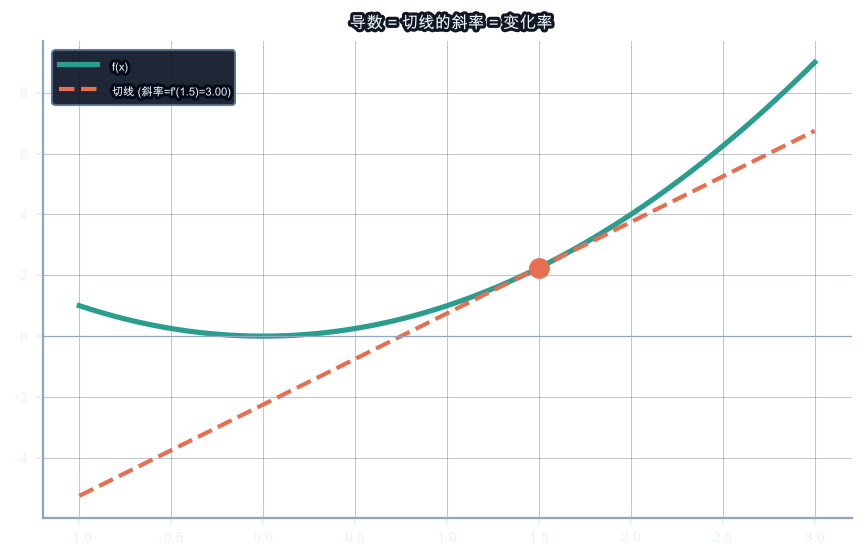

In [6]:
tangent(lambda x: x**2, lambda x: 2*x, x0=1.5);

## 2. 一维梯度下降：沿斜坡滚到最低点（对应 L25）

## 从切线到梯度下降：沿着下坡方向走

**关键观察**：导数的符号决定了函数的「上下趋势」。

对 $f(x) = x^2$：
- 在 $x = -2$ 处，$f'(-2) = 2 \times (-2) = -4 < 0$，往右走函数值会减小（下坡）
- 在 $x = 2$ 处，$f'(2) = 2 \times 2 = 4 > 0$，往右走函数值会增大（上坡）
- 在 $x = 0$ 处，$f'(0) = 0$，这里是底部（平地）

**梯度下降的核心规则**：沿着「**-导数**的方向」走一小步。
$$x_{\text{新}} = x - \text{学习率} \times f'(x)$$

为什么加负号？因为：
- 若 $f'(x) > 0$（上坡），$-f'(x) < 0$，我们往左走（减小 x）
- 若 $f'(x) < 0$（下坡），$-f'(x) > 0$，我们往右走（增大 x）

无论在哪里，「$-f'(x)$ 方向」总是指向函数值更低的地方。这就是「最陡下降方向」的含义。

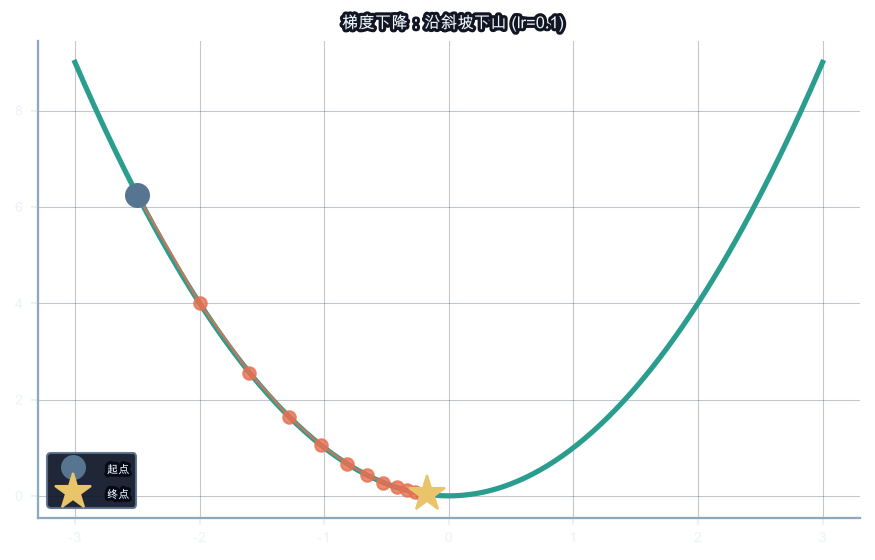

In [7]:
descent_1d(lambda x:(x)**2, lambda x:2*x, x0=-2.5, lr=0.1);

## 3. 二维梯度下降：垂直等高线下山（对应 L23 梯度 + L25）

**Aurora**：`contour_descent(start, lr, steps)` 画出的折线就是神经网络参数更新路径的缩影。Aurora 的音频损失函数（如谱重建损失）将在后续里程碑中实现；届时每步更新规则与此处完全一致（`x ← x − lr·∇f`），只是参数空间从二维扩展到数百万维，折线变成了超高维空间里的一条轨迹。

### 偏导数（partial derivative）：多变量里的「方向导数」

从一维到多维，核心思想是一样的，但我们需要问：「在某个方向上，函数变化得多快？」

对函数 $f(x,y)$，我们可以问两个问题：
1. **固定 y，只改变 x**：$f$ 对 $x$ 的**偏导数** $\frac{\partial f}{\partial x}$
2. **固定 x，只改变 y**：$f$ 对 $y$ 的**偏导数** $\frac{\partial f}{\partial y}$

**计算方法**：把另一个变量当成常数来求导。

**例子**：$f(x,y) = x^2 + 2y^2$
- $\frac{\partial f}{\partial x} = 2x$（把 $2y^2$ 当常数，$(x^2)' = 2x$）
- $\frac{\partial f}{\partial y} = 4y$（把 $x^2$ 当常数，$(2y^2)' = 4y$）

在点 $(x,y) = (1,2)$ 处：
- $\frac{\partial f}{\partial x}\bigg|_{(1,2)} = 2 \times 1 = 2$
- $\frac{\partial f}{\partial y}\bigg|_{(1,2)} = 4 \times 2 = 8$

### 梯度向量（gradient）：最陡上升的方向

把两个偏导数打包成一个向量，叫做**梯度**：
$$\nabla f = \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right)$$

几何含义：$\nabla f$ 在某点指向**函数值增长最快的方向**。它的反方向 $-\nabla f$ 就指向**函数值下降最快的方向**（最陡下坡）。

对 $f(x,y) = x^2 + 2y^2$ 在点 $(1,2)$ 处：$\nabla f = (2, 8)$

这个向量指向右上方，意思是：从 $(1,2)$ 开始，往右上走能最快地增加 $f$ 的值。反过来，往左下走能最快地减小 $f$ 的值。

### 等高线（contour line）：同一高度的点的轨迹

想象你站在一座山上俯视。等高线是地图上**高度相同的点连接起来的曲线**。

对 $f(x,y)$，等高线 $c$ 上的所有点 $(x,y)$ 都满足 $f(x,y) = c$（常数）。

**关键几何事实**：**梯度垂直于等高线**。

为什么？因为等高线上的点，函数值都一样。梯度是「函数值变化最快的方向」，那么在等高线**切线方向**上，函数值不变（因为同高度）。所以梯度必然垂直于这条切线，即垂直于等高线本身。

**梯度下降的可视化**：每一步都沿着 $-\nabla f$ 走，即垂直等高线、指向更低的那一侧。

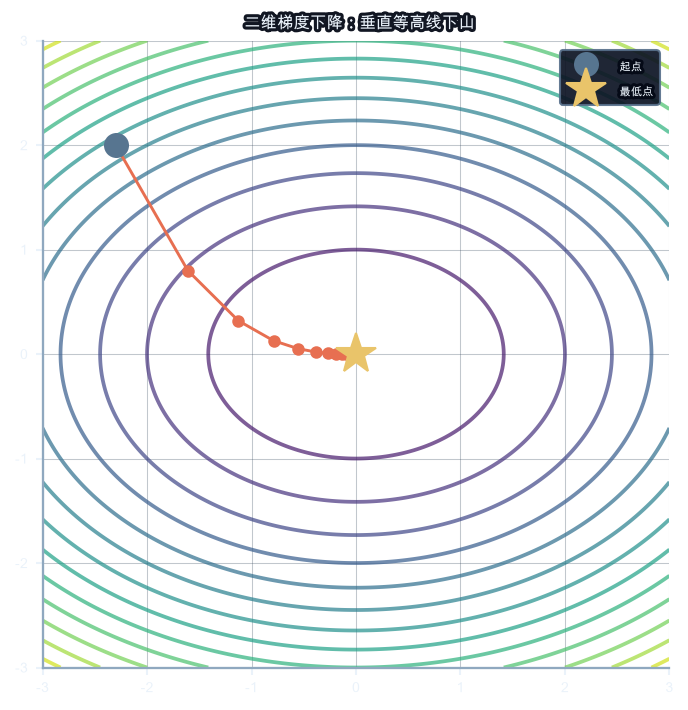

In [8]:
contour_descent(start=(-2.3, 2.0), lr=0.15);

## 4. 学习率的影响：太小慢 / 适中 / 太大震荡

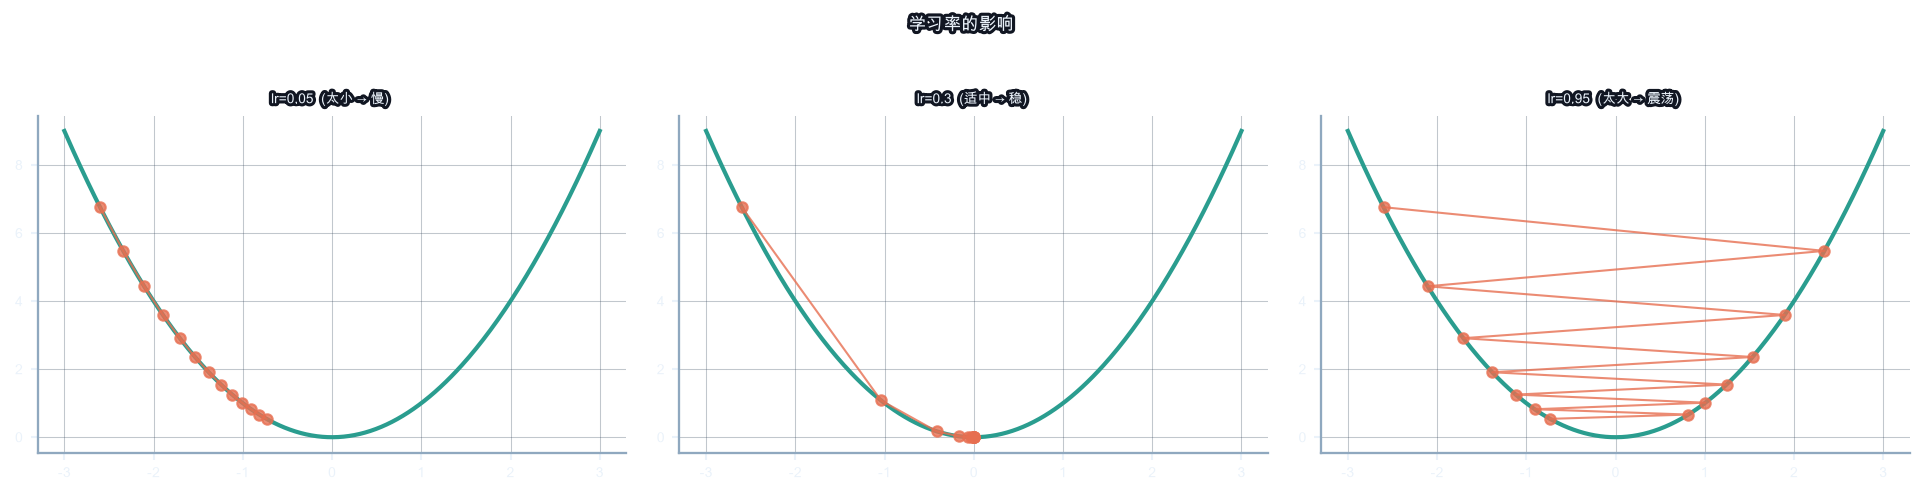

In [9]:
lr_compare();

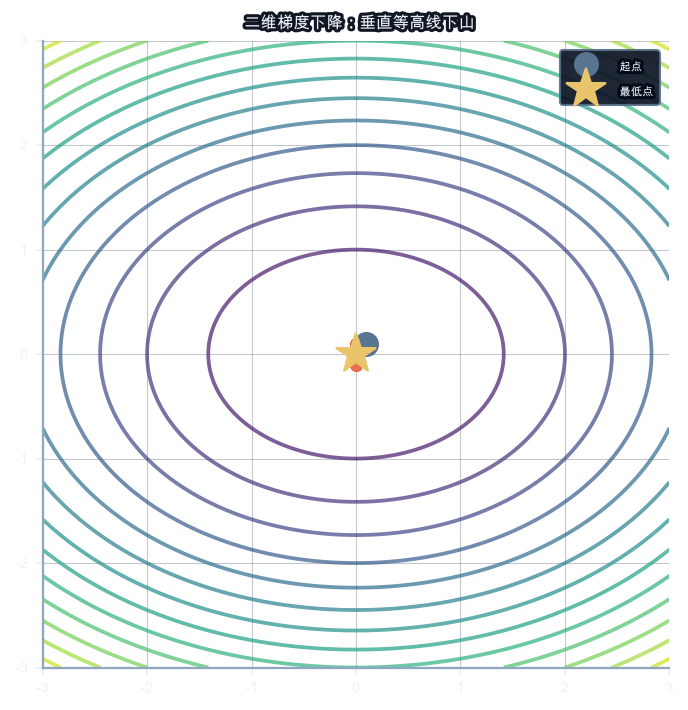

In [10]:
# 参数实验 1：从极小值点旁出发，lr=0.5 观察振荡
contour_descent(start=(0.1, 0.1), lr=0.5)
# 预期：f(x,y)=x²+2y² 是凸函数，(0,0) 是全局极小值；lr 较大时轨迹在极值点附近左右弹跳


## 参数实验：从极小值（minimum）旁边出发

在 `contour_descent` 里把 `start` 改为 `(0.1, 0.1)`，让轨迹从极小值点旁边出发。注意：`f(x,y)=x²+2y²` 是**凸函数**，(0,0) 处是全局极小值而非鞍点（saddle point）。真正的鞍点需要函数在某方向上升、另一方向下降，例如 `f(x,y)=x²−y²`。梯度下降对凸函数必然收敛；深度学习中的非凸损失才会出现鞍点。

### 凸函数（convex function）的定义和判断

**直观定义**：如果函数的图像像一个「碗」或「山谷」的形状，那它就是凸的。更准确地说，函数上任意两点的连线都在函数图像上方。

**数学定义**：对任意两点 $x_1, x_2$ 和任意 $0 \leq t \leq 1$：
$$f(t \cdot x_1 + (1-t) \cdot x_2) \leq t \cdot f(x_1) + (1-t) \cdot f(x_2)$$

**判断方法**（对二阶导数存在的函数）：
- **一维**：$f''(x) \geq 0$ 对所有 $x$ 成立 $\Rightarrow$ 凸函数
- **二维**：Hessian 矩阵（二阶偏导组成的矩阵）是**半正定**的

**例子**：
- $f(x) = x^2$ 的二阶导数是 $f''(x) = 2 > 0$，所以是凸的
- $f(x,y) = x^2 + 2y^2$ 的 Hessian 是 $\begin{pmatrix} 2 & 0 \\ 0 & 4 \end{pmatrix}$（特征值都是正数），所以是凸的

**梯度下降的保证**：对凸函数，**任何局部极小值都是全局极小值**，梯度下降必然收敛到真正的最优解。

### 鞍点（saddle point）：既不是山峰也不是山谷

**直观定义**：函数在某点沿某些方向增大（像山脊），沿另一些方向减小（像山谷）。这个点看起来像马鞍的形状。

**例子**：$f(x,y) = x^2 - y^2$ 在原点 $(0,0)$
- 沿 $x$ 轴方向：$f(x,0) = x^2$，这是个山谷（$x=0$ 是最小值）
- 沿 $y$ 轴方向：$f(0,y) = -y^2$，这是个山峰（$y=0$ 是最大值）

这个函数的 Hessian 是 $\begin{pmatrix} 2 & 0 \\ 0 & -2 \end{pmatrix}$（特征值有正有负），所以有鞍点。

**梯度下降的困境**：在鞍点附近，梯度可能很小（导致更新步幅很小），或者算法在不同方向的来回摇摆，难以逃脱。这是**非凸优化**的主要难题。

对比实验：保持 `start=(0.1, 0.1)`，把 `lr` 从 `0.15` 改成 `0.5`，观察轨迹是否在极值点附近左右弹跳；再把 `lr` 降回 `0.05`，看收敛步数如何随之增加。

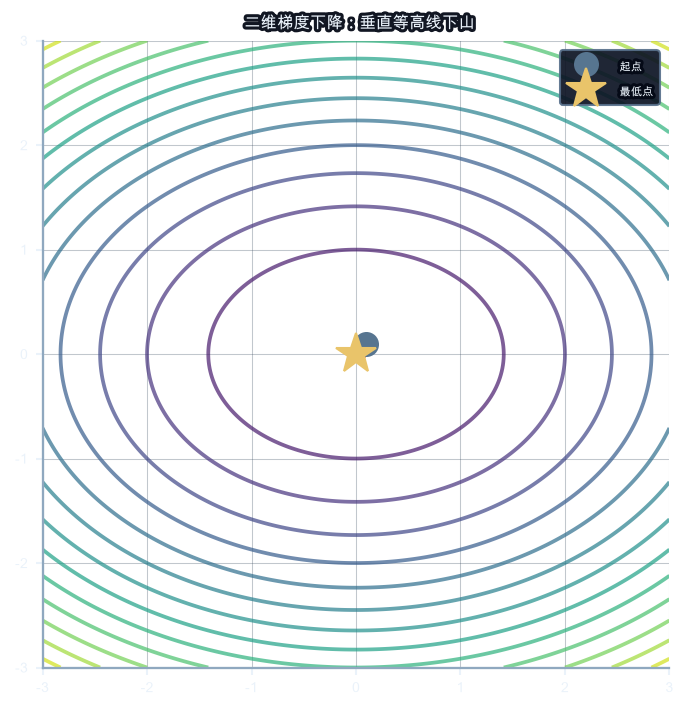

In [11]:
# 对比实验：同一起点，lr=0.05 观察慢收敛
contour_descent(start=(0.1, 0.1), lr=0.05)
# 预期：每步步幅小，路径稳定趋向极值点，步数明显多于 lr=0.5


### 学习率的收敛条件：什么时候会发散？

梯度下降的更新规则是 $x_{\text{新}} = x - \text{lr} \cdot f'(x)$。什么时候这个迭代会发散？

**一维情形**：对 $f(x) = x^2$，导数 $f'(x) = 2x$，更新成为：
$$x_{\text{新}} = x - \text{lr} \cdot 2x = (1 - 2 \cdot \text{lr}) \cdot x$$

每次迭代，$x$ 乘以因子 $(1 - 2 \cdot \text{lr})$。为了让 $x$ 趋向 0，这个因子的绝对值必须 $< 1$：
$$|1 - 2 \cdot \text{lr}| < 1$$

展开这个不等式：
$$-1 < 1 - 2 \cdot \text{lr} < 1$$
$$-2 < -2 \cdot \text{lr} < 0$$
$$0 < \text{lr} < 1$$

**结论**：对 $f(x) = x^2$，学习率必须满足 $0 < \text{lr} < 1$ 才能收敛。
- $\text{lr} = 0.1$ 或 $0.5$：都在范围内，会收敛
- $\text{lr} = 1.1 > 1$：会发散（每步 $x$ 的绝对值增大）
- $\text{lr} = -0.5 < 0$：会发散（每步 $x$ 的绝对值增大）

**二维推广**：条件变得更复杂（涉及目标函数的二阶导数信息），但核心思想一样：学习率太大会破坏稳定性。

## 本课收束

现在能用 `tangent` 在任意点画切线，用 `descent_1d` 和 `contour_descent` 把梯度下降的每一步轨迹可视化，用 `lr_compare` 并排看三种学习率的收敛差异。这条折线轨迹就是 Aurora 模型训练时 `loss` 曲线的几何来源：每个训练步（iteration）的 loss 值对应参数空间里的一个位置，打印出来的是它在损失轴上的高度。`L25` 已把同样的更新规则 `x ← x − lr·∇f(x)` 用在直线拟合的 MSE 损失上，形式完全一样。

### 梯度下降轨迹与 loss 曲线的对应关系

想象你在一个 **参数空间** 里迭代：
- **水平面**：两个参数 $x$ 和 $y$（如直线拟合中的斜率和截距）
- **竖直轴**：损失函数 $f(x,y)$（如 MSE）

**梯度下降轨迹**（折线）：在水平面上，从某个起点开始，每步沿 $-\nabla f$ 移动，最终螺旋收敛到最低点 $(0,0)$。

**loss 曲线**（一维曲线）：每一步的轨迹点 $(x_t, y_t)$，对应的损失值 $f(x_t, y_t)$ 排成一个序列，就是 loss 随 epoch 下降的曲线。

**两者的联系**：
- 轨迹折线在水平面上的投影，对应参数的更新历史
- loss 曲线是从上往下「俯视」这条折线，看每个位置的高度

比方说，轨迹的前5步是 $(2,2) \to (1,1) \to (0.5,0.5) \to \ldots$，对应的 loss 值可能是 $10 \to 2.5 \to 0.625 \to \ldots$，这就绘成了一条下降的 loss 曲线。

In [12]:
import numpy as np

# 微积分可视化数学性质断言（独立运行，无需 cviz 或学生实现）

# 1. 中心差分精度：f(x)=x² 在多个点，误差应 < 1e-8
f = lambda x: x**2
h = 1e-5
for xv in [-2.0, -1.0, 0.0, 1.5, 3.0]:
    cd = (f(xv + h) - f(xv - h)) / (2 * h)
    analytical = 2 * xv
    err = abs(cd - analytical)
    assert err < 1e-8, f"x={xv}: CD误差{err:.2e}过大"
print("中心差分 ✅  f(x)=x² 在5个点的CD误差均 < 1e-8")

# 2. 2D梯度：f(x,y)=x²+2y², ∇f=(2x,4y)，在(1,2)处=[2,8]
f2d = lambda p: p[0]**2 + 2 * p[1]**2
grad_f2d = lambda p: np.array([2 * p[0], 4 * p[1]])
p0 = np.array([1.0, 2.0])
g_analytical = grad_f2d(p0)
assert np.allclose(g_analytical, [2., 8.], atol=1e-12)
# 数值梯度
g_num = np.zeros(2)
hh = 1e-6
for i in range(2):
    ev = np.zeros(2); ev[i] = hh
    g_num[i] = (f2d(p0 + ev) - f2d(p0 - ev)) / (2 * hh)
assert np.allclose(g_num, g_analytical, atol=1e-8)
print(f"2D梯度   ✅  ∇f(1,2)={g_analytical}，数值={np.round(g_num,6)}")

# 3. GD收敛：从x=-2.5出发，lr=0.1，50步后x应接近0
f1d = lambda x: x**2
grad_f1d = lambda x: 2 * x
x = -2.5; lr = 0.1
for _ in range(50):
    x = x - lr * grad_f1d(x)
assert abs(x) < 1e-4, f"GD未收敛到0，得到 {x}"
print(f"GD收敛   ✅  50步后 x={x:.6f}≈0  （lr=0.1，f(x)=x²，起点x=-2.5）")

# 4. 发散条件：lr=1.1 > 1，(x-3)² 不收敛
grad_f4 = lambda x: 2 * (x - 3)
x4 = 0.0; lr4 = 1.1
trajectory = [x4]
for _ in range(10):
    x4 = x4 - lr4 * grad_f4(x4)
    trajectory.append(x4)
assert abs(trajectory[-1]) > abs(trajectory[0]), "lr=1.1时应发散"
print(f"发散条件 ✅  lr=1.1，x轨迹绝对值增大：{[round(v,1) for v in trajectory[:5]]}...")
print("\n所有微积分可视化数学性质验证通过 ✅")

中心差分 ✅  f(x)=x² 在5个点的CD误差均 < 1e-8
2D梯度   ✅  ∇f(1,2)=[2. 8.]，数值=[2. 8.]
GD收敛   ✅  50步后 x=-0.000036≈0  （lr=0.1，f(x)=x²，起点x=-2.5）
发散条件 ✅  lr=1.1，x轨迹绝对值增大：[0.0, 6.6, -1.3, 8.2, -3.2]...

所有微积分可视化数学性质验证通过 ✅


In [ ]:
# ✏️ 本课自评
l26_review = {
    "tangent_visualized":        None,  # 能解释切线 = 局部线性近似？True/False
    "descent_trajectory_seen":   None,  # 看过 descent/contour 轨迹图？True/False
    "lr_compare_understood":     None,  # 能对比不同 lr 的收敛/发散？True/False
    "l25_connection":            None,  # 理解与 L25 gd_step 同一更新规则？True/False
}

unfilled = [k for k, v in l26_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l26_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L26 全部通关！进入 L27：概率基础')


---
⬇️ **通关检验**：收束小结已读；请运行下方数学性质验证格，再勾选自评。


---

→ **下一课**　[L27 · 概率基础](../4_probability/L27_probability_basics.ipynb)

> 下节课将学习 **概率基础**：事件、条件概率、独立性与大数定律。